# Comparacion de modelos de clasificacion HistGradientBoosting, LightGBM, CatBoost, XGBoost

In [2]:
# Standard libraries
import os
import warnings

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV

# Statistical distributions
from scipy.stats import loguniform, randint, uniform

# Typing utilities
from typing import Dict, Any, List, Optional, Tuple




In [3]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [4]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

In [5]:
# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
df = df.set_index('SamplingOperations_code')
 
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'CodeSite_SamplingOperations', 'Date_SamplingOperation'])
df

TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      NaN      NaN   
S02000008_20200708                                    400      NaN      NaN   
S02000010_20070906                                    400      NaN      NaN   
S02000010_20090721                                    400      NaN      NaN   
S02000010_20110723                                    398      NaN      NaN   
...                                                   ...      ...      ...   
S06940940_20100708                                    438      NaN      NaN   
S06940940_20230623                                    408      NaN      NaN   
S06960950_20160629                                    401      NaN      NaN   
S06960950_20180719                                    416      NaN      NaN   
S06970900_20150601                                    432      NaN      NaN   

                         Achaf01    Achaf02  Achal01  Acham01  Achan01  \
SamplingOperations_code                                                  
S02000008_20170703           NaN        NaN      NaN      NaN      NaN   
S02000008_20200708           NaN        NaN      NaN      NaN      NaN   
S02000010_20070906           NaN        NaN      NaN      NaN      NaN   
S02000010_20090721           NaN        NaN      NaN      NaN      NaN   
S02000010_20110723           NaN        NaN      NaN      NaN      NaN   
...                          ...        ...      ...      ...      ...   
S06940940_20100708           NaN        NaN      NaN      NaN      NaN   
S06940940_20230623           NaN        NaN      NaN      NaN      NaN   
S06960950_20160629           NaN        NaN      NaN      NaN      NaN   
S06960950_20180719           NaN  19.230769      NaN      NaN      NaN   
S06970900_20150601           NaN        NaN      NaN      NaN      NaN   

                         Achat01   Achat02  Achat03  Achba01  Achbi01  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN       NaN      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN  6.944444      NaN      NaN      NaN   

                         Achbi02   Achbr01  Achca01  Achca02  Achca03  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN  2.283105      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN       NaN      NaN      NaN      NaN   

                         Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
SamplingOperations_code                              

# For each region

In [6]:
import cleandf

In [7]:
# For all regions 1, 2, ..., 22
regiondfs = {}
for region in range(1, 2):
    print(f"Region: {region}")
    regiondf = df[df['HERlvl1Code'] == region]

    cleanregion = cleandf.IWANTMYXCLEAN(regiondf, thresh_high_missing=.99)
    regiondfs[region] = cleanregion

Region: 1
Dropped exact duplicate columns: ['Achac01', 'Achal01', 'Achca01', 'Achch01', 'Achcl01', 'Achco01', 'Achco03', 'Achcy01', 'Achde01', 'Achde02', 'Achdi01', 'Achdi02', 'Achel01', 'Achen01', 'Achex03', 'Achfl01', 'Achfr01', 'Achgr01', 'Achgr02', 'Achha01', 'Achhe01', 'Achhi01', 'Achho01', 'Achho02', 'Achim01', 'Achim02', 'Achim03', 'Achin01', 'Achin02', 'Achjo01', 'Achko01', 'Achkr01', 'Achkr03', 'Achkr04', 'Achku01', 'Achla01', 'Achla05', 'Achle01', 'Achle02', 'Achli02', 'Achli04', 'Achlo01', 'Achlu01', 'Achlu02', 'Achmo01', 'Achmo02', 'Achna01', 'Achna02', 'Achni01', 'Achno01', 'Achpa01', 'Achpe01', 'Achpe02', 'Achpl01', 'Achpo01', 'Achpr01', 'Achpr02', 'Achps01', 'Achps02', 'Achps03', 'Achpu01', 'Achro01', 'Achro03', 'Achru02', 'Achsc01', 'Achse01', 'Achse02', 'Achsi01', 'Achst01', 'Achst02', 'Achst04', 'Achsu02', 'Achsu04', 'Achtu01', 'Achzi01', 'Actde01', 'Actno01', 'Actro01', 'Actse01', 'Actsp01', 'Actsu01', 'Actvu01', 'Adlaq01', 'Adlbr01', 'Adlmu01', 'Adlmu02', 'Adlpa01',

In [8]:
regiondfs[1]

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achca02,Achca04,Achco02,Achco04,Achcr01,Achda01,Achde03,Achdr01,Acheu01,Achex02,Achho03,Achla02,Achla04,Achla06,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achro04,Achst03,Achsu01,Achsu03,Achth01,Achzh01,Adlbr02,Adlmi01,Adlsu01,Ampin01,Ampin02,Amppe01,Amppe02,Aulam01,Calae01,Calba01,Cocdi01,Coceu01,Cocli01,Cocne02,Cocpa01,Cocpe01,Cocpl01,Cycme02,Cycps01,Cymaf02,Cymco01,Cymex01,Cymex02,Cymmi01,Cymre01,Cymsi01,Cymve01,Delde02,Dente01,Diaeh01,Diame01,Diavu01,Didge01,Dipse01,Encmi03,Encmi04,Encsi02,Encsu03,Encvu01,Eucla01,Exiva01,Fraau01,Fraca04,Fragr01,Frami03,Frane04,Frapa01,Frape01,Frare01,Fraru01,Frate01,Frave01,Fruco01,Geiac01,Goman05,Gomca01,Gomca02,Gomcu02,Gomcy01,Gomel01,Gomex01,Gomin06,Gommi01,Gommi02,Gommi03,Gommi05,Gomol03,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Himmi01,Karcl01,Melva01,Merci01,Micgr01,Navan05,Navar02,Navca07,Navca08,Navca10,Navca11,Navcr05,Navcr09,Navcr10,Navde03,Navex02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navpe06,Navra01,Navre04,Navsa03,Navsp02,Navsu03,Navsu07,Navsu08,Navve03,Nitac05,Nitam01,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitla03,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitre01,Nitso01,Nitso04,Nitsu05,Nupla01,Panco02,Plala02,Plesc01,Psabi01,Punra01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selsa02,Suran01,Surla01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,682.500000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,765.000000,15.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,Na

In [13]:
# ============================================================
# ContiguousLabelWrapper + MultiRegionBoostedClassifier (robust)
# ============================================================

from typing import Dict, Any, List, Optional, Tuple
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, uniform
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier

# ---------- utilities ----------

def _resolve_col_case(df: pd.DataFrame, name: str) -> str:
    if name in df.columns:
        return name
    low = name.lower()
    for c in df.columns:
        if c.lower() == low:
            return c
    raise KeyError(f"Column '{name}' not found (case-insensitive).")

def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="None")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
        ],
        remainder="drop",
    )
    return pre, num_cols, cat_cols

def _feature_names_from_pre(pre: ColumnTransformer, num_cols: List[str], cat_cols: List[str]) -> List[str]:
    names: List[str] = []
    if num_cols:
        names.extend(num_cols)
    if cat_cols and "cat" in pre.named_transformers_:
        ohe = pre.named_transformers_["cat"].named_steps["ohe"]
        names.extend(ohe.get_feature_names_out(cat_cols).tolist())
    return names

def _cv_for(y: pd.Series, max_splits: int = 5) -> StratifiedKFold:
    min_class = int(y.value_counts(dropna=False).min())
    # If min_class==1, force n_splits=2 but be aware some folds' TRAIN may miss that class.
    # Wrapper below makes such folds safe for XGB/LGBM.
    n_splits = max(2, min(max_splits, max(1, min_class)))
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

def _can_kfold(y: pd.Series, cv: Optional[StratifiedKFold]) -> bool:
    if cv is None:
        return False
    return int(y.value_counts().min()) >= cv.get_n_splits()

# ---------- core: wrapper to enforce 0..k-1 labels per fit ----------

class ContiguousLabelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps a classifier so that for each fit() it remaps labels present in that TRAIN split
    to {0..k-1}. Predictions are mapped back to the original global integer labels.
    Exposes underlying estimator params via 'estimator__*' for grid search.
    """

    def __init__(self, estimator: BaseEstimator):
        self.estimator = estimator
        self.estimator_ = None
        self.classes_ = None  # array of global int labels present in this fit

    # delegate param handling so RandomizedSearchCV can tune inner estimator
    def get_params(self, deep=True):
        params = {"estimator": self.estimator}
        if deep and hasattr(self.estimator, "get_params"):
            for k, v in self.estimator.get_params(deep=True).items():
                params[f"estimator__{k}"] = v
        return params

    def set_params(self, **params):
        est_params = {}
        for k, v in list(params.items()):
            if k == "estimator":
                self.estimator = v
            elif k.startswith("estimator__"):
                est_params[k.split("__", 1)[1]] = v
            else:
                setattr(self, k, v)
            params.pop(k, None)
        if est_params and hasattr(self.estimator, "set_params"):
            self.estimator.set_params(**est_params)
        return self

    def fit(self, X, y, **fit_params):
        y = np.asarray(y)
        uniq = np.unique(y)
        # map global ints -> contiguous local 0..k-1
        to_local = {g: i for i, g in enumerate(uniq)}
        y_local = np.array([to_local[val] for val in y], dtype=int)
        est = clone(self.estimator)
        est.fit(X, y_local, **fit_params)
        self.estimator_ = est
        self.classes_ = uniq  # keep order aligned with local indices
        return self

    def predict(self, X):
        y_local = self.estimator_.predict(X)
        # map back to global ints using classes_ index
        return self.classes_[np.asarray(y_local, dtype=int)]

    def predict_proba(self, X):
        if not hasattr(self.estimator_, "predict_proba"):
            raise AttributeError("Underlying estimator has no predict_proba.")
        P_local = self.estimator_.predict_proba(X)  # shape (n, k_local)
        # columns already aligned with local indices; report over present classes only
        return P_local

# ---------- main class (robust boosted) ----------

class MultiRegionBoostedClassifier:
    """
    Per-region model selection over boosted trees with safe per-fit contiguous label remapping:
      - HistGradientBoostingClassifier
      - LightGBM (if installed)
      - XGBoost (if installed)
      - CatBoost (if installed)
    Outer LabelEncoder keeps string labels; inner wrapper keeps XGB happy in sparse folds.
    """

    def __init__(self, xcleans: Dict[Any, pd.DataFrame], random_state: int = 42, verbose: bool = True):
        self.xcleans = xcleans
        self.random_state = random_state
        self.verbose = verbose
        self.results: Dict[Any, Dict[str, Any]] = {}
        self.target_column: Optional[str] = None

    def _candidate_spaces(self) -> Dict[str, Tuple[Any, dict]]:
        rng = self.random_state
        spaces: Dict[str, Tuple[Any, dict]] = {}

        # HGB
        hgb = ContiguousLabelWrapper(HistGradientBoostingClassifier(random_state=rng))
        hgb_grid = {
            "model__estimator__learning_rate": loguniform(1e-2, 3e-1),
            "model__estimator__max_depth": randint(2, 13),
            "model__estimator__max_leaf_nodes": randint(16, 257),
            "model__estimator__min_samples_leaf": randint(10, 201),
            "model__estimator__l2_regularization": loguniform(1e-4, 10.0),
            "model__estimator__max_bins": randint(64, 257),
        }
        spaces["HGB"] = (hgb, hgb_grid)

        # LightGBM
        try:
            from lightgbm import LGBMClassifier
            lgb = ContiguousLabelWrapper(LGBMClassifier(objective="multiclass",
                                                        random_state=rng, n_jobs=-1, verbose=-1))
            lgb_grid = {
                "model__estimator__n_estimators": randint(300, 1201),
                "model__estimator__learning_rate": loguniform(1e-2, 3e-1),
                "model__estimator__num_leaves": randint(16, 257),
                "model__estimator__max_depth": randint(-1, 16),
                "model__estimator__min_child_samples": randint(5, 201),
                "model__estimator__subsample": uniform(0.5, 0.5),
                "model__estimator__colsample_bytree": uniform(0.5, 0.5),
                "model__estimator__reg_alpha": loguniform(1e-6, 10.0),
                "model__estimator__reg_lambda": loguniform(1e-6, 10.0),
            }
            spaces["LightGBM"] = (lgb, lgb_grid)
        except Exception:
            if self.verbose: print("[warn] LightGBM not available; skipping.")

        # XGBoost
        try:
            from xgboost import XGBClassifier
            xgb = ContiguousLabelWrapper(XGBClassifier(
                objective="multi:softprob",
                random_state=rng,
                tree_method="hist",
                eval_metric="mlogloss",
                n_jobs=-1,
                verbosity=0,
            ))
            xgb_grid = {
                "model__estimator__n_estimators": randint(300, 1201),
                "model__estimator__learning_rate": loguniform(1e-2, 3e-1),
                "model__estimator__max_depth": randint(3, 13),
                "model__estimator__min_child_weight": loguniform(1e-1, 10.0),
                "model__estimator__subsample": uniform(0.5, 0.5),
                "model__estimator__colsample_bytree": uniform(0.5, 0.5),
                "model__estimator__gamma": loguniform(1e-6, 10.0),
                "model__estimator__reg_alpha": loguniform(1e-6, 10.0),
                "model__estimator__reg_lambda": loguniform(1e-6, 10.0),
            }
            spaces["XGBoost"] = (xgb, xgb_grid)
        except Exception:
            if self.verbose: print("[warn] XGBoost not available; skipping.")

        # CatBoost
        try:
            from catboost import CatBoostClassifier
            cb = ContiguousLabelWrapper(CatBoostClassifier(
                loss_function="MultiClass",
                random_seed=rng,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            ))
            cb_grid = {
                "model__estimator__iterations": randint(300, 1201),
                "model__estimator__learning_rate": loguniform(1e-2, 3e-1),
                "model__estimator__depth": randint(4, 11),
                "model__estimator__l2_leaf_reg": loguniform(1e-3, 30.0),
                "model__estimator__bagging_temperature": loguniform(1e-2, 10.0),
            }
            spaces["CatBoost"] = (cb, cb_grid)
        except Exception:
            if self.verbose: print("[warn] CatBoost not available; skipping.")

        return spaces

    def process_missing_class(
        self,
        target_column: str = "IBD_EQR_Status",
        max_splits: int = 5,
        n_iter_per_model: int = 25,
        scoring: str = "balanced_accuracy",
        calibrate: bool = True,
        prob_method: str = "predict_proba",
    ):
        self.results.clear()
        self.target_column = target_column

        for key, Xclean in self.xcleans.items():
            try:
                y_col = _resolve_col_case(Xclean, target_column)
            except KeyError:
                if self.verbose: print(f"[skip {key}] missing target '{target_column}'"); continue
            if len(Xclean) < 5:
                if self.verbose: print(f"[skip {key}] too few rows: {len(Xclean)}"); continue

            y = Xclean[y_col]
            leak = {y_col, "IBD", "IBD_EQR", "IBD_EQR_Status", "IBD_EQR_STATUS"}
            X = Xclean.drop(columns=[c for c in leak if c in Xclean.columns], errors="ignore")

            mask_tr = y.notna()
            mask_te = ~mask_tr
            if mask_tr.sum() == 0:
                if self.verbose: print(f"[skip {key}] no labeled rows"); continue

            # global string->int encoder
            le = LabelEncoder()
            y_tr = y.loc[mask_tr]
            y_tr_enc = pd.Series(le.fit_transform(y_tr), index=y_tr.index)

            pre, num_cols, cat_cols = _build_preprocessor(X)
            cv = _cv_for(y_tr, max_splits=max_splits)

            candidates = self._candidate_spaces()
            if not candidates:
                raise RuntimeError("No boosted candidates available.")

            best = {"name": None, "estimator": None, "cv_score": -np.inf, "cv_results_": None}
            for name, (estimator, grid) in candidates.items():
                pipe = Pipeline([("pre", pre), ("model", estimator)])
                search = RandomizedSearchCV(
                    estimator=pipe,
                    param_distributions=grid,
                    n_iter=n_iter_per_model,
                    scoring=scoring,
                    cv=cv,
                    refit=True,
                    n_jobs=-1,
                    verbose=0,
                    random_state=self.random_state,
                    error_score=np.nan,  # do not abort if a candidate fails
                )
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    search.fit(X.loc[mask_tr], y_tr_enc)

                # if all folds failed, mean_test_score is NaN
                mean_score = np.nanmax(search.cv_results_["mean_test_score"])
                if self.verbose:
                    print(f"[{key}] {name}: best {scoring}={mean_score:.3f}")
                if np.isfinite(mean_score) and mean_score > best["cv_score"]:
                    best.update({"name": name, "estimator": search.best_estimator_, "cv_score": float(mean_score),
                                 "cv_results_": search.cv_results_})

            if best["estimator"] is None:
                if self.verbose: print(f"[skip {key}] no model selected"); continue

            best_pipe: Pipeline = best["estimator"]

            # OOF diagnostics
            if _can_kfold(y_tr, cv):
                try:
                    oof_pred_enc = cross_val_predict(best_pipe, X.loc[mask_tr], y_tr_enc, cv=cv, method="predict", n_jobs=-1)
                except Exception:
                    oof_pred_enc = cross_val_predict(best_pipe, X.loc[mask_tr], y_tr_enc, cv=cv, method=None, n_jobs=-1)
                oof_pred = pd.Series(le.inverse_transform(oof_pred_enc.astype(int)), index=y_tr.index)
                oof_bal_acc = balanced_accuracy_score(y_tr, oof_pred)
                oof_f1_macro = f1_score(y_tr, oof_pred, average="macro")
                cm = confusion_matrix(y_tr, oof_pred, labels=le.classes_)
            else:
                if self.verbose:
                    print(f"[{key}] skip OOF: min_class={int(y_tr.value_counts().min())} < folds={cv.get_n_splits()}")
                best_pipe.fit(X.loc[mask_tr], y_tr_enc)
                oof_pred_enc = best_pipe.predict(X.loc[mask_tr])
                oof_pred = pd.Series(le.inverse_transform(oof_pred_enc.astype(int)), index=y_tr.index)
                oof_bal_acc = balanced_accuracy_score(y_tr, oof_pred)
                oof_f1_macro = f1_score(y_tr, oof_pred, average="macro")
                cm = confusion_matrix(y_tr, oof_pred, labels=le.classes_)

            cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in le.classes_],
                                 columns=[f"pred_{c}" for c in le.classes_])

            # Refit on all labeled rows
            best_pipe.fit(X.loc[mask_tr], y_tr_enc)

            # Calibration (only if each class has >= folds samples)
            calibrated_pipe = best_pipe
            if calibrate and _can_kfold(y_tr, cv):
                base = best_pipe
                final_est = base.named_steps["model"]
                if hasattr(final_est, "predict_proba") or hasattr(final_est, "decision_function"):
                    calib = CalibratedClassifierCV(final_est, cv=cv, method="isotonic")
                    calibrated_pipe = Pipeline([("pre", base.named_steps["pre"]), ("model", calib)])
                    calibrated_pipe.fit(X.loc[mask_tr], y_tr_enc)
            else:
                if calibrate and self.verbose:
                    print(f"[{key}] skip calibration: min_class={int(y_tr.value_counts().min())} < folds={cv.get_n_splits()}")

            # Predict missing rows
            if mask_te.any():
                X_te = X.loc[mask_te]
                yhat_enc = calibrated_pipe.predict(X_te)
                yhat_te = pd.Series(le.inverse_transform(yhat_enc.astype(int)), index=X_te.index, name="yhat_te")

                # probabilities aligned to present classes of the final fit
                proba_te = pd.DataFrame(index=X_te.index)
                if hasattr(calibrated_pipe, "predict_proba"):
                    P = calibrated_pipe.predict_proba(X_te)
                    # classes_ from inner wrapper are global int labels present in final fit
                    inner = calibrated_pipe.named_steps["model"]
                    classes_enc = getattr(inner, "classes_", None)
                    if classes_enc is None and hasattr(inner, "base_estimator"):
                        classes_enc = getattr(inner.base_estimator, "classes_", None)
                    if classes_enc is None:
                        # try to reach through CalibratedClassifierCV -> estimator_
                        try:
                            classes_enc = inner.estimators_[0].classes_
                        except Exception:
                            classes_enc = np.unique(y_tr_enc)
                    classes = le.inverse_transform(np.array(classes_enc, dtype=int))
                    proba_te = pd.DataFrame(P, index=X_te.index, columns=[f"proba_{c}" for c in classes])
            else:
                yhat_te = pd.Series(dtype=object, name="yhat_te")
                proba_te = pd.DataFrame()

            # Feature importances (if available on final estimator inside wrapper)
            final_est = best_pipe.named_steps["model"]
            pre_fitted = best_pipe.named_steps["pre"]
            feat_names = _feature_names_from_pre(pre_fitted, num_cols, cat_cols)
            fi = pd.Series(dtype=float)
            try:
                est_inner = getattr(final_est, "estimator_", None)
                if est_inner is None and hasattr(final_est, "estimator"):
                    est_inner = final_est.estimator
                if est_inner is not None and hasattr(est_inner, "feature_importances_"):
                    fi = pd.Series(est_inner.feature_importances_, index=feat_names).sort_values(ascending=False)
            except Exception:
                pass

            # Filled target
            y_filled = y.copy()
            if mask_te.any():
                y_filled.loc[mask_te] = yhat_te.values

            # Store
            self.results[key] = {
                "best_name": best["name"],
                "best_cv_score_bal_acc": float(best["cv_score"]),
                "oof_bal_acc": oof_bal_acc,
                "oof_f1_macro": oof_f1_macro,
                "oof_confusion": cm_df,
                "classes_": le.classes_,
                "label_encoder": le,
                "model": calibrated_pipe,
                "uncalibrated_model": best_pipe,
                "n_train": int(mask_tr.sum()),
                "n_infer": int(mask_te.sum()),
                "y_tr": y_tr,
                "oof_pred": pd.Series(oof_pred, index=y_tr.index, name="oof_pred"),
                "yhat_te": yhat_te,
                "proba_te": proba_te,
                "y_filled": y_filled,
                "feature_importances": fi,
            }

            if self.verbose:
                print(f"[done {key}] best={best['name']}  OOF_bal_acc={oof_bal_acc:.3f}  "
                      f"OOF_f1_macro={oof_f1_macro:.3f}  infer={int(mask_te.sum())}")

    # ---- convenience ----

    def infer_table(self, key: Any) -> pd.DataFrame:
        r = self.results[key]
        idx = self.xcleans[key].index
        out = pd.DataFrame(index=idx)
        out["y_true"] = r["y_tr"]
        out["oof_pred"] = r["oof_pred"]
        out["yhat_te"] = r["yhat_te"]
        out["y_filled"] = r["y_filled"]
        out = out.join(r["proba_te"], how="left")
        return out

    def all_inferred(self) -> pd.DataFrame:
        frames = []
        for k in self.results:
            df = self.infer_table(k).reset_index().rename(columns={"index": "row_id"})
            df.insert(0, "region", k)
            frames.append(df)
        return pd.concat(frames, ignore_index=True)

    def filled_dataframe(self, key: Any) -> pd.DataFrame:
        if self.target_column is None:
            raise RuntimeError("Run process_missing_class first.")
        df = self.xcleans[key].copy()
        col = _resolve_col_case(df, self.target_column)
        df[col] = self.results[key]["y_filled"]
        return df

    def top_features(self, key: Any, k: int = 20) -> pd.DataFrame:
        fi = self.results[key]["feature_importances"]
        if fi.empty:
            raise ValueError("Feature importances unavailable for the selected model.")
        return fi.head(k).reset_index().rename(columns={"index": "feature", 0: "importance"})

    def print_report(self, key: Any):
        r = self.results[key]
        y_tr = r["y_tr"]
        y_pred = r["oof_pred"].reindex(y_tr.index)
        print(classification_report(y_tr, y_pred, digits=3))
        print("OOF confusion matrix:")
        print(r["oof_confusion"])

    def plot_oof_confusion(self, key: Any):
        cm = self.results[key]["oof_confusion"]
        plt.figure(figsize=(5, 4))
        plt.imshow(cm.values, interpolation="nearest")
        plt.xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
        plt.yticks(range(len(cm.index)), cm.index)
        plt.title(f"OOF confusion — region {key}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

    def predict_new(self, key: Any, X_new: pd.DataFrame) -> np.ndarray:
        # returns encoded integers; prefer predict_labels_new
        return self.results[key]["model"].predict(X_new)

    def predict_labels_new(self, key: Any, X_new: pd.DataFrame) -> np.ndarray:
        enc = self.results[key]["model"].predict(X_new)
        le: LabelEncoder = self.results[key]["label_encoder"]
        return le.inverse_transform(enc.astype(int))

    def predict_proba_new(self, key: Any, X_new: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        mdl = self.results[key]["model"]
        if not hasattr(mdl, "predict_proba"):
            raise AttributeError("Model does not support predict_proba.")
        P = mdl.predict_proba(X_new)
        inner = mdl.named_steps["model"]
        classes_enc = getattr(inner, "classes_", None)
        if classes_enc is None:
            try:
                classes_enc = inner.estimators_[0].classes_
            except Exception:
                classes_enc = np.arange(P.shape[1])
        le: LabelEncoder = self.results[key]["label_encoder"]
        classes = le.inverse_transform(np.array(classes_enc, dtype=int))
        return P, classes


In [14]:
auto = MultiRegionBoostedClassifier(regiondfs, random_state=42, verbose=True)
auto.process_missing_class(target_column="IBD_EQR_STATUS", max_splits=5, n_iter_per_model=2, calibrate=True)

[1] HGB: best balanced_accuracy=0.467
[1] LightGBM: best balanced_accuracy=0.469
[1] XGBoost: best balanced_accuracy=0.451
[1] CatBoost: best balanced_accuracy=0.444
[1] skip OOF: min_class=1 < folds=2


c:\Users\herie\miniconda3\envs\a\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[1] skip calibration: min_class=1 < folds=2
[done 1] best=LightGBM  OOF_bal_acc=1.000  OOF_f1_macro=1.000  infer=172


c:\Users\herie\miniconda3\envs\a\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\herie\miniconda3\envs\a\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# JAJAJA EL CATBOOST ME VA A MATAR LA COMPU JAJEAOJEOAJA NURIA LO HIZO EN ESTO WOW! 

In [15]:
tbl = auto.infer_table(1)
tbl

,y_true,oof_pred,yhat_te,y_filled,proba_Bad,proba_Good,proba_High,proba_Moderate,proba_Poor
SamplingOperations_code,,,,,,,,,
S05168100_20070809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20080806,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20090625,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20100629,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20110809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
S06175540_20150728,NaN,NaN,High,High,9.662609e-16,7.394090e-14,1.000000e+00,4.439366e-19,1.227307e-16
S06175600_20170904,NaN,NaN,High,High,1.743114e-09,3.081008e-07,9.999948e-01,4.842233e-06,1.829199e-09
S06175600_20180926,NaN,NaN,Good,Good,4.149477e-08,9.724843e-01,2.751561e-02,1.152115e-11,4.804551e-08


In [16]:
df_filled = auto.filled_dataframe(1)
df_filled

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achca02,Achca04,Achco02,Achco04,Achcr01,Achda01,Achde03,Achdr01,Acheu01,Achex02,Achho03,Achla02,Achla04,Achla06,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achro04,Achst03,Achsu01,Achsu03,Achth01,Achzh01,Adlbr02,Adlmi01,Adlsu01,Ampin01,Ampin02,Amppe01,Amppe02,Aulam01,Calae01,Calba01,Cocdi01,Coceu01,Cocli01,Cocne02,Cocpa01,Cocpe01,Cocpl01,Cycme02,Cycps01,Cymaf02,Cymco01,Cymex01,Cymex02,Cymmi01,Cymre01,Cymsi01,Cymve01,Delde02,Dente01,Diaeh01,Diame01,Diavu01,Didge01,Dipse01,Encmi03,Encmi04,Encsi02,Encsu03,Encvu01,Eucla01,Exiva01,Fraau01,Fraca04,Fragr01,Frami03,Frane04,Frapa01,Frape01,Frare01,Fraru01,Frate01,Frave01,Fruco01,Geiac01,Goman05,Gomca01,Gomca02,Gomcu02,Gomcy01,Gomel01,Gomex01,Gomin06,Gommi01,Gommi02,Gommi03,Gommi05,Gomol03,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Himmi01,Karcl01,Melva01,Merci01,Micgr01,Navan05,Navar02,Navca07,Navca08,Navca10,Navca11,Navcr05,Navcr09,Navcr10,Navde03,Navex02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navpe06,Navra01,Navre04,Navsa03,Navsp02,Navsu03,Navsu07,Navsu08,Navve03,Nitac05,Nitam01,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitla03,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitre01,Nitso01,Nitso04,Nitsu05,Nupla01,Panco02,Plala02,Plesc01,Psabi01,Punra01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selsa02,Suran01,Surla01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,682.500000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,765.000000,15.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,Na

In [17]:
all_preds = auto.all_inferred()
all_preds

,region,SamplingOperations_code,y_true,oof_pred,yhat_te,y_filled,proba_Bad,proba_Good,proba_High,proba_Moderate,proba_Poor
0,1,S05168100_20070809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
1,1,S05168100_20080806,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
2,1,S05168100_20090625,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
3,1,S05168100_20100629,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
4,1,S05168100_20110809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1480,1,S06175540_20150728,NaN,NaN,High,High,9.662609e-16,7.394090e-14,1.000000e+00,4.439366e-19,1.227307e-16
1481,1,S06175600_20170904,NaN,NaN,High,High,1.743114e-09,3.081008e-07,9.999948e-01,4.842233e-06,1.829199e-09
1482,1,S06175600_20180926,NaN,NaN,Good,Good,4.149477e-08,9.724843e-01,2.751561e-02,1.152115e-11,4.804551e-08
1483,1,S06175645_20220809,NaN,NaN,Good,Good,5.407725e-08,9.423099e-01,5.750759e-02,1.818663e-04,6.290693e-07


In [18]:
auto.print_report(1)

              precision    recall  f1-score   support

         Bad      1.000     1.000     1.000         1
        Good      1.000     1.000     1.000       232
        High      1.000     1.000     1.000       988
    Moderate      1.000     1.000     1.000        86
        Poor      1.000     1.000     1.000         6

    accuracy                          1.000      1313
   macro avg      1.000     1.000     1.000      1313
weighted avg      1.000     1.000     1.000      1313

OOF confusion matrix:
               pred_Bad  pred_Good  pred_High  pred_Moderate  pred_Poor
true_Bad              1          0          0              0          0
true_Good             0        232          0              0          0
true_High             0          0        988              0          0
true_Moderate         0          0          0             86          0
true_Poor             0          0          0              0          6


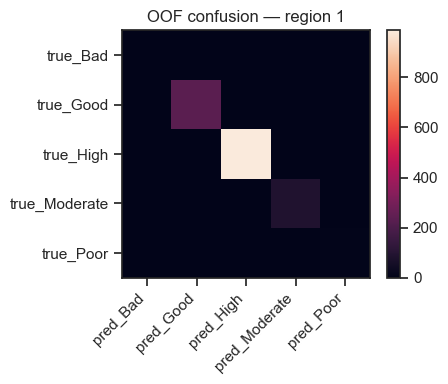

In [19]:
auto.plot_oof_confusion(1)

In [20]:
auto.results[1]["best_name"], auto.results[1]["oof_bal_acc"]

('LightGBM', 1.0)

# Get predictions

In [22]:
all_cls = all_preds.set_index('SamplingOperations_code')
yhat_te = all_cls['yhat_te'][all_cls['yhat_te'].notna()]
yhat_te = yhat_te.to_frame()
yhat_te.to_csv('IBD_EQR_Status_predictions_5663.csv')
yhat_te

,yhat_te
SamplingOperations_code,
S05169000_20130911,High
S05169000_20200819,High
S05172000_20210813,Good
S05172050_20210824,High
S05172350_20120827,High
...,...
S06175540_20150728,High
S06175600_20170904,High
S06175600_20180926,Good


# **LETS KEEP THE LIGHTGBM AS THE BEST MODEL FOR NOW**